### Name:- Adarsh Yadav
### Roll No:- 23107001
### Class:- AIDS-A

### Title: Develop an AI model to analyze social media sentiment trends for financial markets.
---


In [ ]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Sem 6/AIPD/Dataset/data.csv")

In [ ]:
df

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral
...,...,...
5837,RISING costs have forced packaging producer Hu...,negative
5838,Nordic Walking was first used as a summer trai...,neutral
5839,"According shipping company Viking Line , the E...",neutral
5840,"In the building and home improvement trade , s...",neutral


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


In [ ]:
df.rename(columns={
    "Sentence":"text",
    "Sentiment":"sentiment"
}, inplace=True)

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+","",text)   # remove URLs
    text = re.sub(r"@\w+","",text)      # remove mentions
    text = re.sub(r"#\w+","",text)      # remove hashtags
    text = re.sub(r"\$[A-Za-z]+","",text) # remove stock tickers
    text = re.sub(r"[^a-zA-Z ]","",text)

    words = text.split()

    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

In [ ]:
sentiment_map = {
    "negative":0,
    "neutral":1,
    "positive":2
}

df["label"] = df["sentiment"].map(sentiment_map)

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_text"])

y = df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)

Accuracy: 0.7014542343883661
Precision: 0.6787987127240298
Recall: 0.7014542343883661
F1 Score: 0.6688357168357388


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.44      0.13      0.20       175
           1       0.69      0.90      0.78       622
           2       0.77      0.64      0.70       372

    accuracy                           0.70      1169
   macro avg       0.63      0.56      0.56      1169
weighted avg       0.68      0.70      0.67      1169



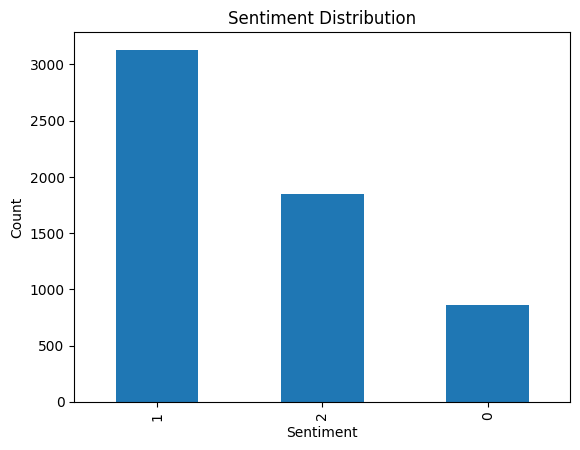

In [ ]:
df["label"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

In [ ]:
def predict_sentiment(text):

    text = clean_text(text)

    vector = vectorizer.transform([text])

    prediction = model.predict(vector)[0]

    if prediction == 0:
        return "Negative"
    elif prediction == 1:
        return "Neutral"
    else:
        return "Positive"


print(predict_sentiment("Tesla stock will surge after AI announcement"))

print(predict_sentiment("Market crash coming soon"))

Positive
Neutral
